##### Medical Insurance Cost Prediction 🩺

In [1]:
#import  libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection  import train_test_split, GridSearchCV, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.compose import TransformedTargetRegressor

from sklearn.metrics import mean_absolute_error,root_mean_squared_error, r2_score

c:\Users\Dilsh\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
sns.set_theme(style="whitegrid")

#plot settings
plt.rcParams.update(
    {
        'figure.figsize': (10, 6),
        'axes.titlesize': 12,
        'axes.labelsize': 8,
        'xtick.labelsize': 8,
        'ytick.labelsize': 8
    }
)

CSV_PATH = "../Data set/insurance.csv"
TARGET_COL="charges"

Loding Data

In [3]:
#load the dataset
df=pd.read_csv(CSV_PATH)

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


In [5]:
#data set shape
print(f"Dataset shape: {df.shape}")

Dataset shape: (1338, 7)


EDA

In [6]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [8]:
#separete into numeric and categorical columns
num_cols=df.select_dtypes(include=np.number).columns.tolist()
cat_cols=df.select_dtypes(include=object).columns.tolist()

print(f"Numeric columns: {num_cols}")
print(f"Categorical columns: {cat_cols}")

Numeric columns: ['age', 'bmi', 'children', 'charges']
Categorical columns: ['sex', 'smoker', 'region']


C:\Users\Dilsh\AppData\Local\Temp\ipykernel_24496\2080509276.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=df.select_dtypes(include=object).columns.tolist()


In [9]:
# identify missing values
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [10]:
# check presence o encoded missing values
for col in df.columns:
    print(df[col].value_counts().head())

age
18    69
19    68
46    29
52    29
48    29
Name: count, dtype: int64
sex
male      676
female    662
Name: count, dtype: int64
bmi
32.300    13
28.310     9
28.880     8
34.100     8
30.800     8
Name: count, dtype: int64
children
0    574
1    324
2    240
3    157
4     25
Name: count, dtype: int64
smoker
no     1064
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
charges
1639.563     2
16884.924    1
1725.552     1
4449.462     1
21984.471    1
Name: count, dtype: int64


In [11]:
#check duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

print("One duplicates found in the dataset dropped .")
df.drop_duplicates(inplace=True)

Number of duplicate rows: 1
One duplicates found in the dataset dropped .


In [12]:
df[num_cols].describe()

,age,bmi,children,charges
count,1337.000,1337.000,1337.000,1337.000
mean,39.222,30.663,1.096,13279.121
std,14.044,6.100,1.206,12110.360
min,18.000,15.960,0.000,1121.874
25%,27.000,26.290,0.000,4746.344
50%,39.000,30.400,1.000,9386.161
75%,51.000,34.700,2.000,16657.717
max,64.000,53.130,5.000,63770.428


In [13]:
for col in cat_cols:
    print(df[col].value_counts())

sex
male      675
female    662
Name: count, dtype: int64
smoker
no     1063
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


Data Visualization

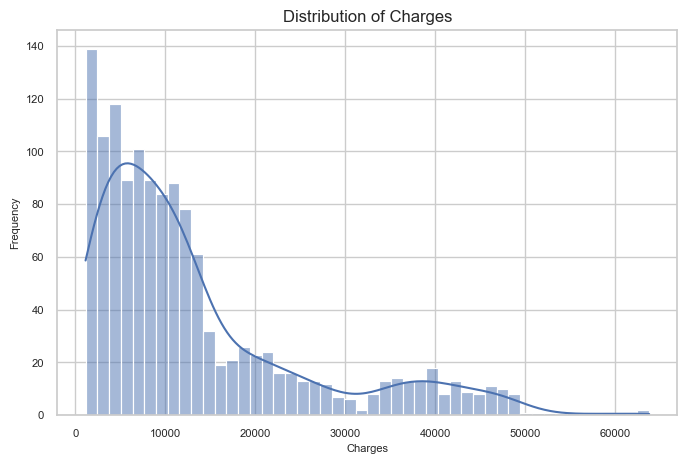

In [14]:
#target columns distribution
plt.figure(figsize=(8, 5))
sns.histplot(df[TARGET_COL],bins=48, kde=True)
plt.title("Distribution of Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

When the mean is greater than the median, it indicates that the data distribution is positively skewed, also known as right-skewed

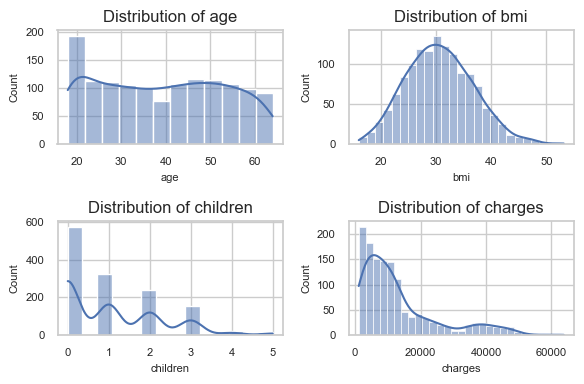

In [15]:
# histogram plot -distribution 

fig,axes=plt.subplots(2,2, figsize=(6,4))
axes=axes.flatten()

for i,col in enumerate(num_cols):
    sns.histplot(df[col],  kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

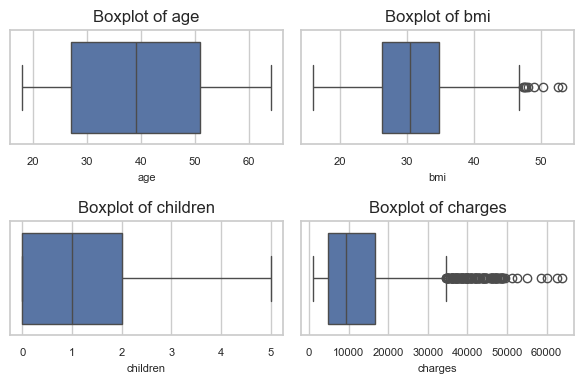

In [16]:
#outliers detection using boxplot

fig,axes=plt.subplots(2,2, figsize=(6,4))
axes=axes.flatten()

for i,col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

In [17]:
#get count of eatch column outliers
for col in num_cols:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    outliers=df[(df[col]<lower_bound) | (df[col]>upper_bound)]
    print(f"Number of outliers in {col}: {outliers.shape[0]}")


Number of outliers in age: 0
Number of outliers in bmi: 9
Number of outliers in children: 0
Number of outliers in charges: 139


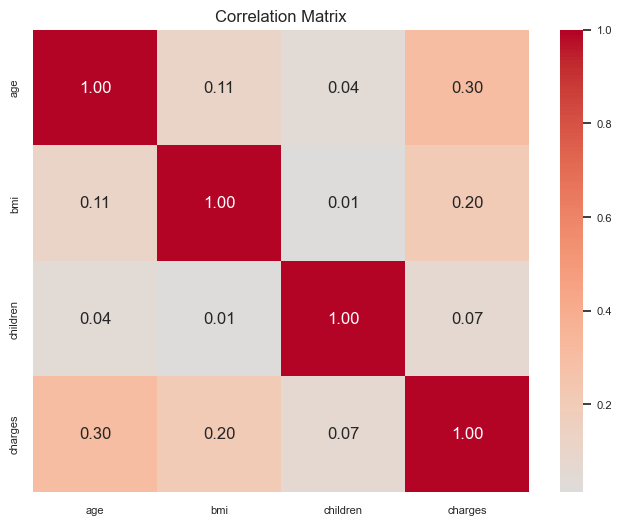

In [18]:
#corilation matrix
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Correlation Matrix")
plt.show()

In [19]:
#correlation with target variable
corr_with_traget=df[num_cols].corr()[TARGET_COL].sort_values(ascending=False)
print("Correlation with target variable:")
print(corr_with_traget)

Correlation with target variable:
charges    1.000
age        0.298
bmi        0.198
children   0.067
Name: charges, dtype: float64


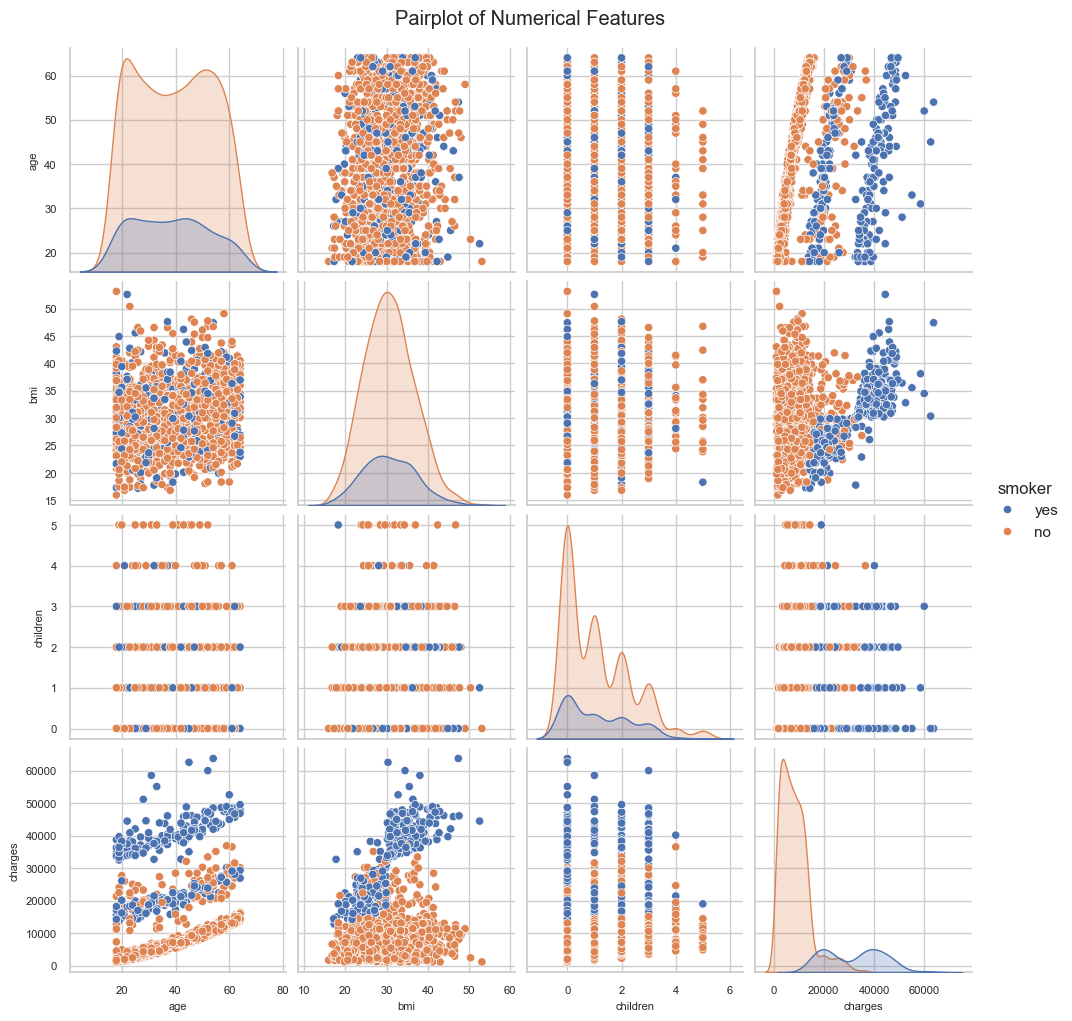

In [20]:
#pairplot
pairplot_col=num_cols+["smoker"]
df_pair=df[pairplot_col].dropna()
sns.pairplot(df_pair, hue="smoker", diag_kind="kde")
plt.suptitle("Pairplot of Numerical Features", y=1.02)
plt.show()

Data Preprocesing


In [21]:
# split data into train and test sets
x=df.drop(columns=[TARGET_COL])
y=df[TARGET_COL]


In [22]:
x.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [23]:
y.head()

0   16884.924
1    1725.552
2    4449.462
3   21984.471
4    3866.855
Name: charges, dtype: float64

In [ ]:
#train test split 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [25]:
#save x_train, x_test, y_train, y_test pkl files
x_train.to_pickle("../model/x_train.pkl")
x_test.to_pickle("../model/x_test.pkl")
y_train.to_pickle("../model/y_train.pkl")
y_test.to_pickle("../model/y_test.pkl")

In [28]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1069, 6)
(268, 6)
(1069,)
(268,)
